In [34]:
import numpy as np
import matplotlib.pyplot as plt
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit
import time as T

cd = "CDY170"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.47

# symmetrical shape

In [31]:
name_dict = dict(
    data1 = dict(amp=0.1, date="2024-11-13", acquire_time="121442", params=dict(fit_start=400, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data2 = dict(amp=0.2, date="2024-11-13", acquire_time="131116", params=dict(fit_start=300, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data4 = dict(amp=0.4, date="2024-11-13", acquire_time="134406", params=dict(fit_start=200, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data6 = dict(amp=0.6, date="2024-11-13", acquire_time="140529", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data8 = dict(amp=0.8, date="2024-11-13", acquire_time="141626", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False, skip=[20])), 
    data9 = dict(amp=0.9, date="2024-11-13", acquire_time="142248", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False, skip=[18, 19, 20])), 
    data10 = dict(amp=1.0, date="2024-11-13", acquire_time="152212", params=dict(fit_start=80, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
)

# Generating Control Pulses

In [37]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

0.1 2024-11-13 121442
0.2 2024-11-13 131116
0.4 2024-11-13 134406
0.6 2024-11-13 140529
0.8 2024-11-13 141626
0.9 2024-11-13 142248
1.0 2024-11-13 152212


KeyboardInterrupt: 

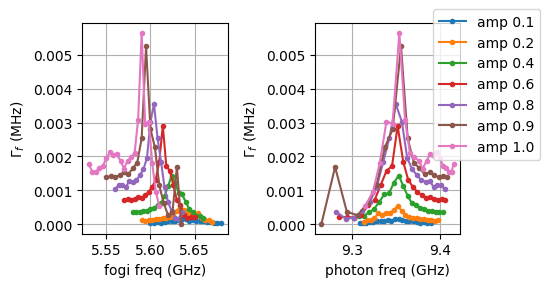

{'a0': 0, 'a2': 0.004853330202705175, 'a4': 1.1266543253896089e-12, 'a6': 1.2096990076315706e-12, 'a8': 4.218847493575595e-15, 'a10': 4.083400284571326e-13}
[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.99

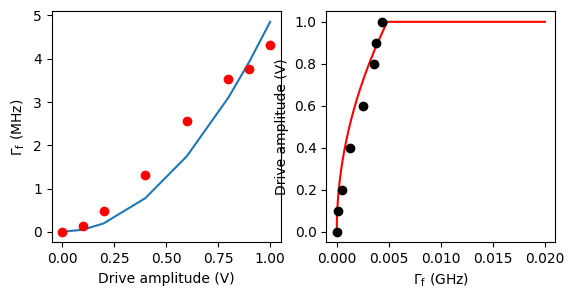

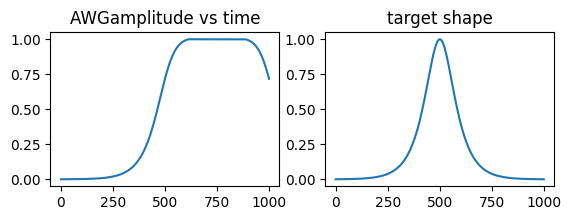

[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.99999291e-01
 9.99999264e-01 9.99999236e-01 9.99999206e-01 9.99999176e-01
 9.99999145e-01 9.99999113e-01 9.99999079e-01 9.99999045e-01
 9.99999010e-01 9.999989

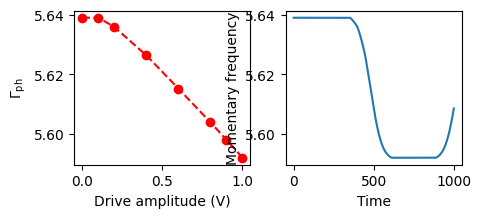

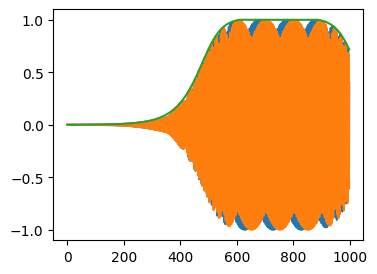

In [8]:
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.39, target_freq, duration, const=const, form="sech_0", tr=False)[0]

## save

In [9]:
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
forms = ["sech_0", "sech_1", "sech_2", "sech_3"] 

for form in forms:
    for target_freq in [9.35]:
        control_pulse, control_envelope = dataobj.generate_control_pulse(
            5.53, target_freq, duration, const=const, form=form, plot=False, tr=False
        )

        note = f"""
        form : {form}
        const : {const / 2 / np.pi}
        duration : {duration}
        target frequency : {target_freq} GHz
        """

        data = DataDict(
            time=dict(unit="ns"),
            control_pulse=dict(axes=["time"]),
            control_envelope=dict(axes=["time"])
        )
        data.validate()

        save_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}"

        with DDH5Writer(data, save_path, name="Control_Pulse") as writer:
            writer.add_tag(["control_pulse", cd, form])
            writer.save_text("target_shape.md", note)
            writer.add_data(
                time=np.arange(len(control_pulse)),
                control_pulse=control_pulse,
                control_envelope=control_envelope
            )
        T.sleep(1)


{'a0': 0, 'a2': 0.004853330202705175, 'a4': 1.1266543253896089e-12, 'a6': 1.2096990076315706e-12, 'a8': 4.218847493575595e-15, 'a10': 4.083400284571326e-13}
[1.00000000e+00 9.99999995e-01 9.99999990e-01 9.99999985e-01
 9.99999980e-01 9.99999974e-01 9.99999968e-01 9.99999962e-01
 9.99999956e-01 9.99999950e-01 9.99999943e-01 9.99999937e-01
 9.99999930e-01 9.99999923e-01 9.99999915e-01 9.99999908e-01
 9.99999900e-01 9.99999892e-01 9.99999884e-01 9.99999875e-01
 9.99999866e-01 9.99999857e-01 9.99999848e-01 9.99999838e-01
 9.99999828e-01 9.99999817e-01 9.99999807e-01 9.99999796e-01
 9.99999784e-01 9.99999772e-01 9.99999760e-01 9.99999748e-01
 9.99999735e-01 9.99999721e-01 9.99999708e-01 9.99999693e-01
 9.99999679e-01 9.99999664e-01 9.99999648e-01 9.99999632e-01
 9.99999615e-01 9.99999598e-01 9.99999580e-01 9.99999562e-01
 9.99999543e-01 9.99999524e-01 9.99999504e-01 9.99999483e-01
 9.99999462e-01 9.99999439e-01 9.99999417e-01 9.99999393e-01
 9.99999369e-01 9.99999344e-01 9.99999318e-01 9.99

# Photon shaping analysis

In [1]:
from Analysis import SechPhotonAnalysis
import numpy as np
import matplotlib.pyplot as plt
cd = "CDY170"

Form: sech_0, Symmetry: 0.9831361766803987, Overlap: 0.9971796333279285
Form: sech_1, Symmetry: 0.7833754901094266, Overlap: 0.9354246291859584
Form: sech_2, Symmetry: 0.5848760830787402, Overlap: 0.8989041290393502
Form: sech_3, Symmetry: 0.7074764416632591, Overlap: 0.894040183974616


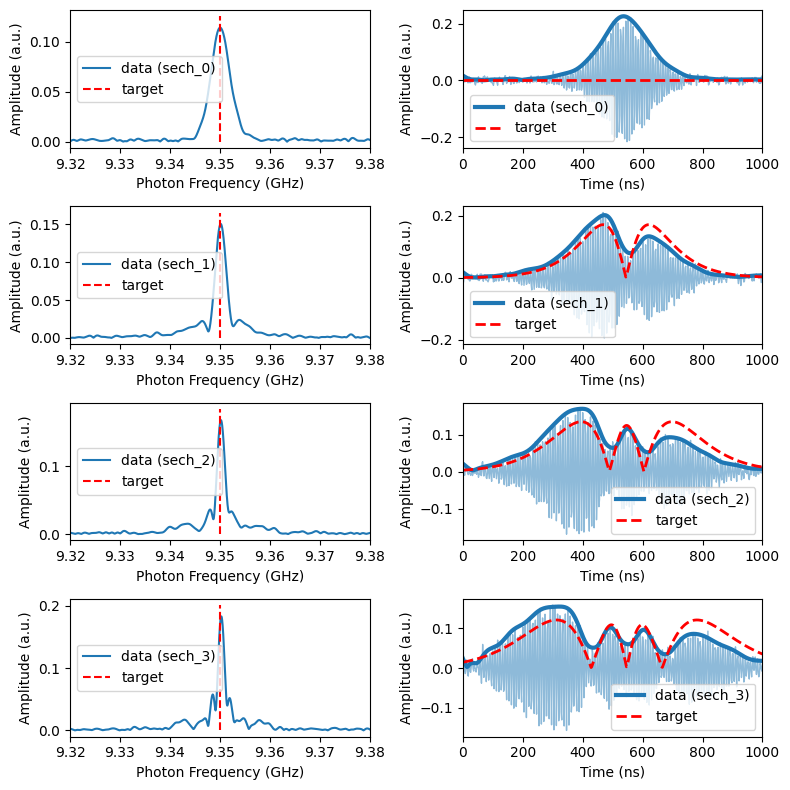

In [2]:
data_path = f"D:\\K_Sunada\\result\\{cd}"
readout_lo_freq = 9.47
duration = 1000
const = 2.5e-3 * 2 * np.pi
passing_band = 0.01

result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2024-11-13", acquire_time="215308", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2024-11-13", acquire_time="215400", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2024-11-13", acquire_time="215451", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2024-11-13", acquire_time="215542", form="sech_3"),
}

analyzer = SechPhotonAnalysis(data_path, result_dict, duration, const, readout_lo_freq)
analyzer.analyze_waveforms(passing_band)

In [27]:
def fit_waveform(time, data, x0=[2.5e-3,600], get_center=False, curve='sech', **kwargs):
    if curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="sech_1":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_2":
        func = lambda x: np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_3":
        func = lambda x: np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave).conj()
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

def target_overlap(wave, time, curve='sech'):
    if curve=='sech':
        target = 1 / np.cosh(const * (time-time[-1]/2))
    elif curve=="sech_1":
        target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_2":
        target = np.abs(((time-time[-1]/2)**2-(np.pi/2/const)**2/3) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_3":
        target = np.abs(((time-time[-1]/2)**3-(7*(time-time[-1]/2)*(np.pi/(2*const))**2/5)) / np.cosh(const * (time-time[-1]/2)))
    norm1=np.sqrt(np.sum(np.abs(wave)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(target)**2) * (time[1]-time[0]))
    m1_t = np.abs(wave / norm1)
    m2_t = target / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

In [25]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    sign_change = np.diff(np.sign(diff_envelope))

    inflection_points = np.where(sign_change == 2)[0] 
    
    return inflection_points

def flip_control_envelope(control_envelope, zero_points):
    flipped_envelope = control_envelope.copy()
    
    for i in range(len(zero_points)):  
        if i % 2 == 0:
            start = zero_points[i] + 1
            end = zero_points[i+1] + 1 if i+1 < len(zero_points) else len(control_envelope)
            flipped_envelope[start:end] *= -1  
    
    return flipped_envelope

symmetry 0.6049755180753738, overlap 0.9195977842539425


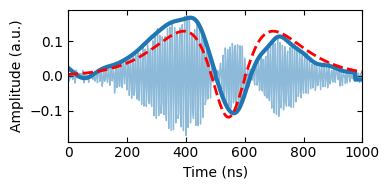

In [29]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import optimize
from datataking import search_datadict_miyamura
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}"
result_dict = {
    # "data_sech_0": dict(target_freq=9.35, date="2024-11-13", acquire_time="221055", form="sech_0"),
    # "data_sech_1": dict(target_freq=9.35, date="2024-11-13", acquire_time="221150", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2024-11-13", acquire_time="221242", form="sech_2"),
    # "data_sech_3": dict(target_freq=9.35, date="2024-11-13", acquire_time="221334", form="sech_3"),
}
for k, v in result_dict.items():
    fig = plt.figure(figsize=(4, 2))
    # ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 1, 1)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    zero_points = find_zero_point(envelope=np.abs(signal))
    flipped_env = flip_control_envelope(np.abs(signal), zero_points)
    res = fit_waveform(time, np.abs(signal), curve="sech_2", kappa=const)
    zero_points = find_zero_point(envelope=res)
    flipped_envelope = flip_control_envelope(res, zero_points)

    ax2.plot(time, 1000*waveform, "tab:blue", lw=1, alpha=0.5)
    ax2.plot(time, 1000*flipped_env, "tab:blue",  lw=3, label="data")
    ax2.plot(time, 1000*flipped_envelope, "r--", lw=2, label="target", alpha=1)
    # ax2.plot(time, 1000*signal.real, "tab:blue", label="real", ls="--")
    # ax2.plot(time, 1000*signal.imag, "tab:blue",label="imag", ls="-.")
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    ax2.tick_params(top='on',bottom='on',left='on',right='on',)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech_2')}")
# plt.legend()
plt.tight_layout()
plt.savefig('photon2.png', bbox_inches='tight')

phase subtraction

In [3]:
ctrl_pulse_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\"
# analyzer.phase_subtraction_and_pulse_flip(ctrl_pulse_path)

corrected photon shaping

In [33]:
corrected_result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2024-11-13", acquire_time="221055", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2024-11-13", acquire_time="221150", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2024-11-13", acquire_time="221242", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2024-11-13", acquire_time="221334", form="sech_3"),
}

corrected_analyzer = SechPhotonAnalysis(data_path, corrected_result_dict, duration, const, readout_lo_freq)
corrected_analyzer.analyze_waveforms(passing_band)

NameError: name 'SechPhotonAnalysis' is not defined

fogi pulse generation for absoption

[7.17711741e-01 7.23326208e-01 7.28894695e-01 7.34415531e-01
 7.39887104e-01 7.45307854e-01 7.50676273e-01 7.55990917e-01
 7.61250395e-01 7.66453383e-01 7.71598617e-01 7.76684892e-01
 7.81711078e-01 7.86676103e-01 7.91578966e-01 7.96418732e-01
 8.01194533e-01 8.05905571e-01 8.10551113e-01 8.15130499e-01
 8.19643134e-01 8.24088490e-01 8.28466106e-01 8.32775589e-01
 8.37016611e-01 8.41188907e-01 8.45292276e-01 8.49326579e-01
 8.53291741e-01 8.57187741e-01 8.61014620e-01 8.64772472e-01
 8.68461450e-01 8.72081757e-01 8.75633647e-01 8.79117423e-01
 8.82533436e-01 8.85882083e-01 8.89163802e-01 8.92379076e-01
 8.95528423e-01 8.98612401e-01 9.01631602e-01 9.04586653e-01
 9.07478210e-01 9.10306961e-01 9.13073615e-01 9.15778916e-01
 9.18423622e-01 9.21008519e-01 9.23534408e-01 9.26002114e-01
 9.28412468e-01 9.30766325e-01 9.33064550e-01 9.35308017e-01
 9.37497610e-01 9.39634222e-01 9.41718753e-01 9.43752108e-01
 9.45735195e-01 9.47668925e-01 9.49554211e-01 9.51391967e-01
 9.53183102e-01 9.549285

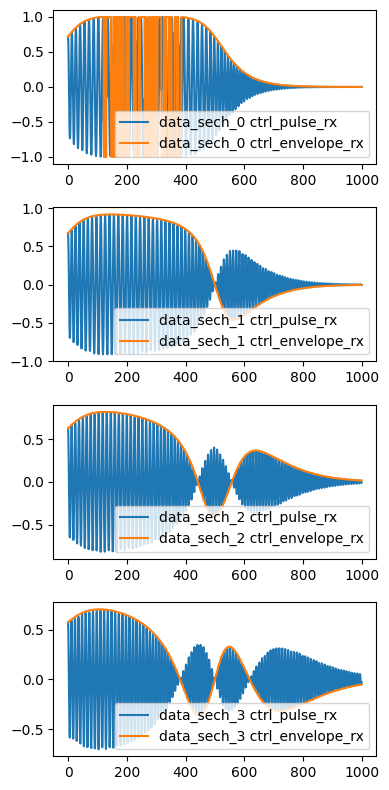

In [4]:
analyzer.generate_control_pulse_rx(ctrl_pulse_path)